# Introduction to Pandas


## Today's agenda

- Talk about 🐼 (not that kind of panda)
- Pandas data structures
- Reading and writing CSV files to disk
- Exploring and summarizing data
- Subsetting Data
- Transforming Data


In [1]:
# First, we need to load pandas into memory and give it the name "pd"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Diving into Pandas

- Pandas is a 3rd-party library for doing data analysis
- It is a foundational component of Python data science
- Developed by [Wes McKinney](http://wesmckinney.com/pages/about.html) while working in the finance industry, so it has some...warts
- Vanilla Python (what we did yesterday) can do many of the same things, but Pandas does them _faster_ and usually _easier_
- To do this, pandas introduces a set of data structures and analysis functions


---


## Introduction to Pandas Data Structures

- To understand Pandas, which is hard, it is helpful to start the data structures it adds to Python:
  - Series - For one dimensional data (lists)
  - Dataframe - For two dimensional data (spreadsheets)
  - Index - For naming, selecting, and transforming data within a Pandas Series or Dataframe (column and row names)


### Series

- A one-dimensional array of indexed data
- Kind of like a blend of a Python list and dictionary
- You can create them from a Python list


In [2]:
pd.Series()

Series([], dtype: object)

In [3]:
# Create a regular Python list
my_list = [0.25, 0.5, 0.75, 1.0]

# Transform that list into a Series
data = pd.Series(my_list)

# Display the data in the series
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

- A Series is a list-like structure, which means it is _ordered_
- You can use indexing to grab items in a Series, just like a list
- Those numbers next to the other numbers, that is the _index_ to the series
- It is best to use the `iloc` method to grab elements by their location in the series.


In [4]:
# grab the first element
data[0]

np.float64(0.25)

In [5]:
# grab the first element using iloc
data.iloc[0]

np.float64(0.25)

In [6]:
# grab the 4th elemenet
data.iloc[3]

np.float64(1.0)

#### Quick Exercise

- How might we grab the _last_ element if we didn't know the length of the list?


In [7]:
# hint: think small
# your code below
data.iloc[-1]


np.float64(1.0)

#### Quick Exercise

- Use index notation to grab the 2nd element of `data`


In [8]:
# hint: the 2nd element is 0.50
# your code below
data.iloc[1]


np.float64(0.5)

- Also, like lists, you can use _slicing_ notation to grab sub-lists
- Again, it is best to use the `.iloc` method

#### Quick Exercise

- Use slices to grab the 2nd and 3rd elements of this series


In [ ]:
# hint: the 2nd & 3rd elements are 0.50 and 0.75
# your code below
data.iloc[1:3]


### Index by name

- Series also act like Python dictionaries, _ordered_ python dictionaries
- This means you can grab things by name in addition to location


In [12]:
# Create a regular Python Dictionary
population_dict = {
    "California": 38332521,
    "Texas": 26448193,
    "New York": 19651127,
    "Florida": 19552860,
    "Illinois": 12882135,
}

# Transform that dictionary into a Series
population = pd.Series(population_dict)

# Display the data
population

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

- You can use indexing and slicing like above, but now with keys instead of numbers!
- It is best to use the `.loc` method when looking up things by name instead of by number


In [13]:
population["California"]

np.int64(38332521)

In [18]:
# select the data value with the name "California"
population.loc[0]

KeyError: 0

In [16]:
# What happens if you try an use a name when it wants
population.iloc["California"]

TypeError: Cannot index by location index with a non-integer key

- Like a Python dictionary, a Series is a list of key/value pairs
- But these are _ordered_, which means you can do slicing


#### Quick Exercise

- Try slicing this series, but with keys instead of numbers!
- Select a subset of the data using the Python slicing notation
- Don't forget, use `loc`!


In [14]:
# Hint: Use the same : notation, but use the state names listed above
# Your code here:

population.loc["California":"Texas"]

California    38332521
Texas         26448193
dtype: int64

In [15]:
sorted_population = population.sort_values(ascending=False)
sorted_population

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [16]:
population

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [17]:
sorted_population

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

### DataFrame

- `DataFrames` are the real workhorse of Pandas and Python Data Science
- We will be spending a lot of time with data inside of Dataframes, so buckle up!
- `DataFrames` contain two-dimensional data, just like an Excel spreadsheet
- In practice, a `DataFrame` is a bunch of `Series` lined up next to each other


In [19]:
# Start with our population Series
population

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

In [20]:
# Then create another Series for the area
area_dict = {
    "Illinois": 149995,
    "California": 423967,
    "Texas": 695662,
    "Florida": 170312,
    "New York": 141297,
    "Ohio": 00000,
}
area = pd.Series(area_dict)
area

Illinois      149995
California    423967
Texas         695662
Florida       170312
New York      141297
Ohio               0
dtype: int64

In [21]:
# Create a dictionary with a key:value for each column
state_info_dictionary = {"population": population, "area": area}

# Now mash them together into a DataFrame
states = pd.DataFrame(state_info_dictionary)
# Display the data
states

,population,area
California,38332521.0,423967
Florida,19552860.0,170312
Illinois,12882135.0,149995
New York,19651127.0,141297
Ohio,NaN,0
Texas,26448193.0,695662


- Pandas automatically lines everything up because they have shared index values


In [22]:
# create a list of dictionaries that contain our data.
# one dictionary per observation/row
dead_people = [
    {"ssn": 1, "first_name": "Bob", "last_name": "Jones", "age": 200},
    {"ssn": 2, "first_name": "Jane", "last_name": "Jones", "age": 199},
    {"ssn": 3, "first_name": "Ethel", "last_name": "Jones", "age": 180},
    {"ssn": 4, "first_name": "Hortense", "last_name": "Jones", "age": 178},
    {"ssn": 5, "first_name": "Vern", "last_name": "Jones", "age": 178, "test": 1},
]

# create a Dataframe from a list of dictionaries
pd.DataFrame(dead_people)

,ssn,first_name,last_name,age,test
0,1,Bob,Jones,200,NaN
1,2,Jane,Jones,199,NaN
2,3,Ethel,Jones,180,NaN
3,4,Hortense,Jones,178,NaN
4,5,Vern,Jones,178,1.0


In [27]:
# create a list of lists, each sub-list is an observation/row
dead_people = [
    [1, "Bob", "Jones", 200],
    [2, "Jane", "Jones", 199],
    [3, "Ethel", "Jones", 180],
    [4, "Hortense", "Jones", 178],
    [5, "Vern", "Jones", 178],
]

# specify the column names seperately
column_names = ["ssn", "first_name", "last_name", "age"]

# make a Dataframe with column names specified separately
pd.DataFrame(dead_people)

,0,1,2,3
0,1,Bob,Jones,200
1,2,Jane,Jones,199
2,3,Ethel,Jones,180
3,4,Hortense,Jones,178
4,5,Vern,Jones,178


In [28]:
# create a list of lists, each sub-list is an observation/row
dead_people = [
    [1, "Bob", "Jones", 200],
    [2, "Jane", "Jones", 199],
    [3, "Ethel", "Jones", 180],
    [4, "Hortense", "Jones", 178],
    [5, "Vern", "Jones", 178],
]

# specify the column names seperately
column_names = ["ssn", "first_name", "last_name", "age"]

row_ids = [123, 3452, 3235, 4345, 563463]

# make a Dataframe with column names specified separately
pd.DataFrame(dead_people, columns=column_names, index=row_ids)

,ssn,first_name,last_name,age
123,1,Bob,Jones,200
3452,2,Jane,Jones,199
3235,3,Ethel,Jones,180
4345,4,Hortense,Jones,178
563463,5,Vern,Jones,178


In [ ]:
df = pd.read_csv("file_location")

## Index

- Pandas `Series` and `DataFrames` are containers for data
- The Index (and Indexing) is the mechanism to make that data retrievable
- In a `Series` the index is the key to each value in the list
- In a `DataFrame` the index is the column names, but there is also an index for each row
- Indexing allows you to merge or join disparate datasets together


In [29]:
states

,population,area
California,38332521.0,423967
Florida,19552860.0,170312
Illinois,12882135.0,149995
New York,19651127.0,141297
Ohio,NaN,0
Texas,26448193.0,695662


- The `loc` method I talked about above allows us to select specific rows and columns _by name_.
- Use the syntax `[<row>,<column>]` with index values


In [30]:
# Get the value of the population column from Illinois
states.loc["Illinois", "population"]

np.float64(12882135.0)

- We can also be tricky and use more advanced syntax to do more advanced queries.


In [31]:
# Get the area for states from Florida to Texas
# this is two dimensional slicing
states.loc["Florida":"Texas", "area"]

Florida     170312
Illinois    149995
New York    141297
Ohio             0
Texas       695662
Name: area, dtype: int64

In [ ]:
states['Population'].apply(plus_one)

for idx,val in states.iter()

In [32]:
# Get the area for Florida and Texas
# Use a list to select multiple specific values
states.loc[["Florida", "Texas"], "area"]

Florida    170312
Texas      695662
Name: area, dtype: int64

In [33]:
# Get area and population for Florida and Texas
# use a ":" to specify "all columns"
states.loc[["Florida", "Texas"], :]

,population,area
Florida,19552860.0,170312
Texas,26448193.0,695662


In [35]:
states.loc[:, :]

,population,area
California,38332521.0,423967
Florida,19552860.0,170312
Illinois,12882135.0,149995
New York,19651127.0,141297
Ohio,NaN,0
Texas,26448193.0,695662


- What is happening here is we are passing a list of names for the rows, and using the colon ":" to say "all columns
- OK, this is neat, but let's move on to some _real_ examples

---


These data sets comes form [the #tidytuesday project](https://www.tidytuesday.com/)


In [23]:
video_game_csv = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2019/2019-07-30/video_games.csv"
nhl_season_goal_csv = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2020/2020-03-03/season_goals.csv"
pokemon_csv = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-04-01/pokemon_df.csv"

## Reading Files into a Dataframe

- Once your data is in a Pandas `DataFrame` you can easily use a ton of analytical tools
- You just have to get your data to fit into a dataframe
- Getting data to fit is a big part of the "data janitor" work...it is the craft of data carpentry
- However, as we will see, there is still a lot of carpentry work to do once your data fits into a `DataFrame`


### Open the file and load it into memory

- Pandas provides some very handy functions for reading in CSV files.


In [24]:
# look at a CSV files using the unix command head
!head pokemon_df.csv

id,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,49,65,65,45,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/7/7b/001MS6.png,1,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/001.png
2,ivysaur,2,1,13,142,grass,poison,60,62,63,80,80,60,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/a/a0/002MS6.png,1,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/002.png
3,venusaur,3,2,100,236,grass,poison,80,82,83,100,100,80,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/0/07/003MS6.png,1,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/003.png
4,charmander,4,0.6,8.5,62,fire,NA,39,52,43,60,50,65,#F08030,NA,NA,monster,dragon,//archives.bu

- This is how we open a CSV file with pure Python


In [26]:
# Load up the CSV module
import csv

pokemon_data = "pokemon_df.csv"
# Use Python's context manager to execute file IO operations
with open(pokemon_data, "r") as f:
    # Load the file into the CSV module
    reader = csv.reader(f)
    # Read all the data, and put them into a list using list comprehensions
    pokemons = [row for row in reader]

# let's look at the first 6 lines of the dataset
print(pokemons[:6])

[['id', 'pokemon', 'species_id', 'height', 'weight', 'base_experience', 'type_1', 'type_2', 'hp', 'attack', 'defense', 'special_attack', 'special_defense', 'speed', 'color_1', 'color_2', 'color_f', 'egg_group_1', 'egg_group_2', 'url_icon', 'generation_id', 'url_image'], ['1', 'bulbasaur', '1', '0.7', '6.9', '64', 'grass', 'poison', '45', '49', '49', '65', '65', '45', '#78C850', '#A040A0', '#81A763', 'monster', 'plant', '//archives.bulbagarden.net/media/upload/7/7b/001MS6.png', '1', 'https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/001.png'], ['2', 'ivysaur', '2', '1', '13', '142', 'grass', 'poison', '60', '62', '63', '80', '80', '60', '#78C850', '#A040A0', '#81A763', 'monster', 'plant', '//archives.bulbagarden.net/media/upload/a/a0/002MS6.png', '1', 'https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/002.png'], ['3', 'venusaur', '3', '2', '100', '236', 'grass', 'poison', '80', '82', '83', '100', '100', '80', '#78C850', '#A040A0', '#81

- Pandas can do this much easier using the `read_csv()` function, and pandas can load csv files directly from the internet
- Documentation for the `read_csv()` function: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html#pandas.read_csv


In [27]:
# Open up the csv file the Pandas way
pokemon_df = pd.read_csv(
    pokemon_data, index_col="id"
)  # use the column named id as the row index
# Display the first five rows
pokemon_df.iloc[0:5]

,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
id,,,,,,,,,,,,,,,,,,,,,
1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,49,...,65,45,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/7/7b/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
2,ivysaur,2,1.0,13.0,142,grass,poison,60,62,63,...,80,60,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/a/a0/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
3,venusaur,3,2.0,100.0,236,grass,poison,80,82,83,...,100,80,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/0/07/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
4,charmander,4,0.6,8.5,62,fire,NaN,39,52,43,...,50,65,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/7/7d/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
5,charmeleon,5,1.1,19.0,142,fire,NaN,58,64,58,...,65,80,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/b/be/0...,1.0,https://raw.githubusercontent.com/HybridShivam...


- Notice the index starts at 1 instead of zero, that is because we told Pandas to use the "\_id" column as the row index.
- This is when it is important to understand the difference between `loc` and `iloc`


In [43]:
# Select row by index name
pokemon_df.loc[1]

pokemon                                                    bulbasaur
species_id                                                         1
height                                                           0.7
weight                                                           6.9
base_experience                                                   64
type_1                                                         grass
type_2                                                        poison
hp                                                                45
attack                                                            49
defense                                                           49
special_attack                                                    65
special_defense                                                   65
speed                                                             45
color_1                                                      #78C850
color_2                           

In [44]:
# Select row by index location
pokemon_df.iloc[1]

pokemon                                                      ivysaur
species_id                                                         2
height                                                           1.0
weight                                                          13.0
base_experience                                                  142
type_1                                                         grass
type_2                                                        poison
hp                                                                60
attack                                                            62
defense                                                           63
special_attack                                                    80
special_defense                                                   80
speed                                                             60
color_1                                                      #78C850
color_2                           

---


## Exploring and Summarizing data

- Once your data has been loaded as a Dataframe, you can start using Pandas various functions to quickly explore your data


### Helpful functions for exploring the data


- Looking at parts of the Dataframe
- `<dataframe>.head(n)` - look at the first n rows of the dataframe
- `<dataframe>.tail(n)` - look at the last n rows of the dataframe
- `<dataframe>.sample(n)` - randomly select n rows from the dataframe


In [28]:
# Look at the first 10 rows
pokemon_df.head()

,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
id,,,,,,,,,,,,,,,,,,,,,
1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,49,...,65,45,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/7/7b/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
2,ivysaur,2,1.0,13.0,142,grass,poison,60,62,63,...,80,60,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/a/a0/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
3,venusaur,3,2.0,100.0,236,grass,poison,80,82,83,...,100,80,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/0/07/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
4,charmander,4,0.6,8.5,62,fire,NaN,39,52,43,...,50,65,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/7/7d/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
5,charmeleon,5,1.1,19.0,142,fire,NaN,58,64,58,...,65,80,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/b/be/0...,1.0,https://raw.githubusercontent.com/HybridShivam...


In [29]:
# Look at the last 5 rows
pokemon_df.tail(7)

,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
id,,,,,,,,,,,,,,,,,,,,,
10141,minior-indigo,774,0.3,0.3,175,rock,flying,60,100,60,...,60,120,#B8A038,#A890F0,#B49C64,mineral,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
10142,minior-violet,774,0.3,0.3,175,rock,flying,60,100,60,...,60,120,#B8A038,#A890F0,#B49C64,mineral,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
10143,mimikyu-busted,778,0.2,0.7,167,ghost,fairy,55,90,80,...,105,96,#705898,#EE99AC,#8E679C,indeterminate,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
10144,mimikyu-totem-disguised,778,0.4,2.8,167,ghost,fairy,55,90,80,...,105,96,#705898,#EE99AC,#8E679C,indeterminate,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
10145,mimikyu-totem-busted,778,0.4,2.8,167,ghost,fairy,55,90,80,...,105,96,#705898,#EE99AC,#8E679C,indeterminate,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
10146,kommo-o-totem,784,2.4,207.5,270,dragon,fighting,75,110,125,...,105,85,#7038F8,#C03028,#8336C5,dragon,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
10147,magearna-original,801,1.0,80.5,120,steel,fairy,80,95,115,...,115,65,#B8B8D0,#EE99AC,#C5B0C7,no-eggs,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...


In [30]:
# Grab 5 random rows
pokemon_df.sample(5)

,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
id,,,,,,,,,,,,,,,,,,,,,
73,tentacruel,73,1.6,55.0,180,water,poison,80,70,65,...,120,100,#6890F0,#A040A0,#757CDC,water3,NaN,//archives.bulbagarden.net/media/upload/e/eb/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
644,zekrom,644,2.9,345.0,306,dragon,electric,100,150,120,...,100,90,#7038F8,#F8D030,#905CC7,no-eggs,NaN,//archives.bulbagarden.net/media/upload/e/e9/6...,5.0,https://raw.githubusercontent.com/HybridShivam...
726,torracat,726,0.7,25.0,147,fire,NaN,65,85,50,...,50,90,#F08030,NaN,NaN,ground,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam...
10094,pikachu-original-cap,25,0.4,6.0,112,electric,NaN,35,55,40,...,50,90,#F8D030,NaN,NaN,ground,fairy,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
356,dusclops,356,1.6,30.6,159,ghost,NaN,40,70,130,...,130,25,#705898,NaN,NaN,indeterminate,NaN,//archives.bulbagarden.net/media/upload/f/fe/3...,3.0,https://raw.githubusercontent.com/HybridShivam...


### How many rows and columns?

- `<dataframe>.shape` - return the rows and columns as a python data structure (not a function!)
- `<dataframe>.info()` - Display the datatypes of the index and columns as well as memory usage
- `<dataframe>.describe()` - Compute summary statistics for numerical columns


In [31]:
# How many rows and columns
pokemon_df.shape

(949, 21)

In [32]:
# Inspect the datatypes
pokemon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 949 entries, 1 to 10147
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pokemon          949 non-null    object 
 1   species_id       949 non-null    int64  
 2   height           949 non-null    float64
 3   weight           949 non-null    float64
 4   base_experience  949 non-null    int64  
 5   type_1           949 non-null    object 
 6   type_2           510 non-null    object 
 7   hp               949 non-null    int64  
 8   attack           949 non-null    int64  
 9   defense          949 non-null    int64  
 10  special_attack   949 non-null    int64  
 11  special_defense  949 non-null    int64  
 12  speed            949 non-null    int64  
 13  color_1          949 non-null    object 
 14  color_2          510 non-null    object 
 15  color_f          510 non-null    object 
 16  egg_group_1      949 non-null    object 
 17  egg_group_2      23

- The output above shows us a lot of implementation details about our dataframe
- Data types, number of rows and columns, and the datatype of the column
- Also shows us memory usage, which is useful because memory is a limited resource

- We can also start doing some computations on the data


In [33]:
# Compute summary statistics on the numerical columns
pokemon_df.describe()

,species_id,height,weight,base_experience,hp,attack,defense,special_attack,special_defense,speed,generation_id
count,949.000000,949.000000,949.000000,949.000000,949.000000,949.000000,949.000000,949.000000,949.000000,949.000000,802.000000
mean,400.133825,1.228240,66.213172,150.476291,68.954689,79.472076,74.066386,72.809273,72.217071,69.023182,3.694514
std,239.952021,1.267795,119.952240,76.391816,25.933562,31.946199,30.760762,32.632244,27.676920,29.209260,1.932751
min,1.000000,0.100000,0.100000,36.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.000000
25%,191.000000,0.500000,8.500000,68.000000,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000,2.000000
50%,395.000000,1.000000,28.800000,157.000000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,4.000000
75%,615.000000,1.500000,66.600000,184.000000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.000000
max,802.000000,14.500000,999.900000,608.000000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,7.000000


- The `describe()` function will automatically compute summary statistics for numerical columns and ignore categorical columns


### Counting Numerical Data

- We can use traditional Python functions to get information about our Dataframe.
- The `len()` function tells us the length of the sequence


In [52]:
# use a standard python function to get the length of the sequence
len(pokemons)

950

- So this tells us our dataset has 18,367 rows.
- But this is just information about the dataset itself, it doesn't tell us how many people visited community centers
- How many people visited all the community centers for all time (in the dataset)?
- First let's answer this using pure python


In [53]:
# look at the first ten rows of the data loaded in python
pokemons[0:10]

[['id',
  'pokemon',
  'species_id',
  'height',
  'weight',
  'base_experience',
  'type_1',
  'type_2',
  'hp',
  'attack',
  'defense',
  'special_attack',
  'special_defense',
  'speed',
  'color_1',
  'color_2',
  'color_f',
  'egg_group_1',
  'egg_group_2',
  'url_icon',
  'generation_id',
  'url_image'],
 ['1',
  'bulbasaur',
  '1',
  '0.7',
  '6.9',
  '64',
  'grass',
  'poison',
  '45',
  '49',
  '49',
  '65',
  '65',
  '45',
  '#78C850',
  '#A040A0',
  '#81A763',
  'monster',
  'plant',
  '//archives.bulbagarden.net/media/upload/7/7b/001MS6.png',
  '1',
  'https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/001.png'],
 ['2',
  'ivysaur',
  '2',
  '1',
  '13',
  '142',
  'grass',
  'poison',
  '60',
  '62',
  '63',
  '80',
  '80',
  '60',
  '#78C850',
  '#A040A0',
  '#81A763',
  'monster',
  'plant',
  '//archives.bulbagarden.net/media/upload/a/a0/002MS6.png',
  '1',
  'https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/002.png'

#### What do you want to know about the dataset?


#### Now let's do the same thing with Pandas 😄


### We can also look at the summary statistics individually

- `<dataframe>[<column name>].mean()` - calculate the mean value for the column values
- `<dataframe>[<column name>].std()` - calculate the standard deviation for the column values
- `<dataframe>[<column name>].var()` - calculate the variance value for the column values
- `<dataframe>[<column name>].median()` - calculate the median value for the column values
- `<dataframe>[<column name>].min()` - calculate the minimum value for the column values


In [54]:
# mean attendance per day at all community centers
pokemon_df["weight"].mean()

np.float64(66.21317175974711)

In [55]:
# standard deviation
pokemon_df["weight"].std()

np.float64(119.95223999185822)

In [56]:
# variance
pokemon_df["weight"].var()

np.float64(14388.53987906435)

In [58]:
# median attendance per day at all community centers
pokemon_df["weight"].median()

np.float64(28.8)

In [57]:
# minimum attendance at community centers
pokemon_df["weight"].min()

np.float64(0.1)

- Pandas is not only a tool for working with numerical data
- Lots of functionality for manipulating categorical data too


### Counting Categorical Data

- Just like before we can start counting the distribution of values in the column.
- how many entries per community center (this isn't counting attendance but counting the number of rows per center).


#### The "Pythonic way"


In [59]:
# Create a dictionary to store the counts
type_counter = dict()

# loop over the data
for row in pokemons[1:]:
    # check to see if the gender is already in the dict
    for type in row[6:8]:
        if type not in type_counter:
            # create a new entry
            type_counter[type] = 1
        else:
            # increment a new entry
            type_counter[type] += 1

# Display the dictionary
type_counter

{'grass': 110,
 'poison': 70,
 'fire': 74,
 'NA': 439,
 'flying': 125,
 'water': 144,
 'bug': 84,
 'normal': 118,
 'electric': 73,
 'ground': 76,
 'fairy': 58,
 'fighting': 64,
 'psychic': 100,
 'rock': 79,
 'steel': 59,
 'ice': 44,
 'ghost': 58,
 'dragon': 61,
 'dark': 62}

- The Pandas way is a bit easier


In [60]:
# what happens when you sum a column of string categories
pokemon_df["type_1"].sum()

'grassgrassgrassfirefirefirewaterwaterwaterbugbugbugbugbugbugnormalnormalnormalnormalnormalnormalnormalpoisonpoisonelectricelectricgroundgroundpoisonpoisonpoisonpoisonpoisonpoisonfairyfairyfirefirenormalnormalpoisonpoisongrassgrassgrassbugbugbugbuggroundgroundnormalnormalwaterwaterfightingfightingfirefirewaterwaterwaterpsychicpsychicpsychicfightingfightingfightinggrassgrassgrasswaterwaterrockrockrockfirefirewaterwaterelectricelectricnormalnormalnormalwaterwaterpoisonpoisonwaterwaterghostghostghostrockpsychicpsychicwaterwaterelectricelectricgrassgrassgroundgroundfightingfightingnormalpoisonpoisongroundgroundnormalgrassnormalwaterwaterwaterwaterwaterwaterpsychicbugiceelectricfirebugnormalwaterwaterwaternormalnormalwaterelectricfirenormalrockrockrockrockrocknormaliceelectricfiredragondragondragonpsychicpsychicgrassgrassgrassfirefirefirewaterwaterwaternormalnormalnormalnormalbugbugbugbugpoisonwaterwaterelectricfairynormalfairyfairypsychicpsychicelectricelectricelectricgrasswaterwaterrockwa

In [34]:
# Do the same thing with pandas
pokemon_df["type_1"].value_counts()

type_1
water       126
normal      111
grass        84
bug          79
rock         65
psychic      64
electric     61
fire         59
ghost        40
dragon       39
dark         37
ground       36
poison       35
fighting     31
steel        30
ice          29
fairy        19
flying        4
Name: count, dtype: int64

In [35]:
# Do the same thing with pandas
pokemon_df["type_2"].value_counts()

type_2
flying      121
ground       40
fairy        39
psychic      36
poison       35
fighting     33
steel        29
grass        26
dark         25
dragon       22
ghost        18
water        18
fire         15
ice          15
rock         14
electric     12
normal        7
bug           5
Name: count, dtype: int64

In [36]:
# Do the same thing with pandas
pokemon_df["type_1"].unique()

array(['grass', 'fire', 'water', 'bug', 'normal', 'poison', 'electric',
       'ground', 'fairy', 'fighting', 'psychic', 'rock', 'ghost', 'ice',
       'dragon', 'dark', 'steel', 'flying'], dtype=object)

### Splitting Data with GroupBy

- A common pattern in data analysis is splitting data by a key and then performing some math on all of the values with that key and finally combining it all back together
- This is commonly known in data circles as _split, apply, combine_


- We need to specify what kind of aggregation, transformation, or computation to perform on the group


In [37]:
pokemon_gen_df = pokemon_df[
    [
        "height",
        "weight",
        "base_experience",
        "hp",
        "attack",
        "special_attack",
        "defense",
        "special_defense",
        "speed",
        "generation_id",
    ]
].groupby("generation_id")
pokemon_gen_df.mean()

,height,weight,base_experience,hp,attack,special_attack,defense,special_defense,speed
generation_id,,,,,,,,,
1.0,1.194702,45.951656,135.052980,64.211921,72.913907,67.139073,68.225166,66.086093,69.066225
2.0,1.163000,49.105000,139.380000,70.980000,68.260000,64.500000,69.690000,72.340000,61.410000
3.0,1.229630,67.077778,137.340741,65.666667,73.111111,67.859259,69.007407,66.466667,61.614815
4.0,1.133645,76.885047,158.775701,73.102804,80.214953,73.280374,75.205607,74.476636,69.476636
5.0,1.032051,52.402564,145.692308,70.314103,81.032051,69.243590,71.237179,67.333333,66.596154
6.0,1.068056,51.401389,140.611111,68.916667,72.500000,72.541667,75.222222,74.722222,65.680556
7.0,1.274074,96.455556,128.370370,70.691358,83.160494,73.518519,77.049383,74.839506,64.543210


In [65]:
pokemon_gen_df

In [66]:
pokemon_gen_df.sum()

,height,weight,base_experience,hp,attack,special_attack,defense,special_defense,speed
generation_id,,,,,,,,,
1.0,180.4,6938.7,20393,9696,11010,10138,10302,9979,10429
2.0,116.3,4910.5,13938,7098,6826,6450,6969,7234,6141
3.0,166.0,9055.5,18541,8865,9870,9161,9316,8973,8318
4.0,121.3,8226.7,16989,7822,8583,7841,8047,7969,7434
5.0,161.0,8174.8,22728,10969,12641,10802,11113,10504,10389
6.0,76.9,3700.9,10124,4962,5220,5223,5416,5380,4729
7.0,103.2,7812.9,10398,5726,6736,5955,6241,6062,5228


The following table summarizes some other built-in Pandas aggregations:

| Aggregation          | Description                     |
| -------------------- | ------------------------------- |
| `count()`            | Total number of items           |
| `size()`             | Total number of items w/ NaNs   |
| `first()`, `last()`  | First and last item             |
| `mean()`, `median()` | Mean and median                 |
| `min()`, `max()`     | Minimum and maximum             |
| `std()`, `var()`     | Standard deviation and variance |
| `mad()`              | Mean absolute deviation         |
| `prod()`             | Product of all items            |
| `sum()`              | Sum of all items                |

These are all methods of `DataFrame` and `Series` objects.


#### Quick Exercise

- Using the community center dataframe try the aggregations above


In [67]:
# Try a aggregation function to see what it does by adding it after the period.

pokemon_gen_df.prod()


,height,weight,base_experience,hp,attack,special_attack,defense,special_defense,speed
generation_id,,,,,,,,,
1.0,5.702391e-02,2.834283e+206,0,0,0,0,0,0,0
2.0,4.785968e-04,1.881170e+133,0,0,0,0,0,0,0
3.0,7.998750e-05,1.168048e+193,0,0,0,0,0,0,0
4.0,1.062933e-06,4.271249e+149,0,0,0,0,0,0,0
5.0,7.090339e-11,2.120109e+217,0,0,0,0,0,0,0
6.0,2.245838e-08,4.120695e+88,0,0,0,0,0,-4035225266123964416,0
7.0,1.508368e-07,3.712897e+104,0,0,8178536923304820736,0,0,0,0


In [68]:
# Try a aggregation function to see what it does by adding it after the period.

pokemon_gen_df.size()


generation_id
1.0    151
2.0    100
3.0    135
4.0    107
5.0    156
6.0     72
7.0     81
dtype: int64

---


![](http://i0.kym-cdn.com/photos/images/newsfeed/001/296/855/bff.png)

I am the Data and I speak for the [trees](https://data.wprdc.org/dataset/city-trees).

Analyze PGH tree data with descriptive statistics. Answer the following questions using Pandas and the provided data about Pittsburgh's trees.

- What is the average height and width of trees in Pittsburgh?
- How tall is the tallest tree?
- What is the tallest type of tree in pittsburgh on average?
- Bonus: In what neighborhood is the widest tree?
  - Hint: try the `idxmax()` to get the row id of the max value then select that row by id


In [ ]:
# First step read csv into dataframe
tree_data = pd.read_csv("Tree_data.csv", low_memory=False)
tree_data.head()

**First things first, let's break it down!**

![Break it down corgi](https://media0.giphy.com/media/TRff1szV5FYXu/giphy.gif)


In [ ]:
# What is the average height of Pittsburgh trees?
# Your code below

# We want to work with the column named: height
#


In [ ]:
# How tall is the tallest tree?
# Your code below


In [ ]:
# What is the tallest type of tree in Pittsburgh on average?
# Your code below


In [ ]:
# Bonus: In what neighborhood is the widest tree?
# Your code below


#### Challenge Answers


- What is the average height of Pittsburgh trees?


In [ ]:
# first step, select just the height values of the trees
tree_heights = tree_data["height"]

# second step, compute the mean of those values using the max function
tree_height_mean = tree_heights.mean()

print("The average height of trees in Pittsburgh is", tree_height_mean, "feet")

- What is the average width of Pittsburgh trees?


In [ ]:
# first step, select just the widths of the trees
tree_widths = tree_data["width"]

# second step, compute the mean of those values using the mean fuctions
tree_width_mean = tree_widths.mean()

print("The average width of trees in Pittsburgh is", tree_width_mean, "feet")

- How tall is the tallest tree?


In [ ]:
# first step, use idxmax to get the row index of the max value
tallest_tree = tree_data["height"]

# second step, compute the max value of the heights
tallest_tree_height = tree_heights.max()

print("The tallest tree is", tallest_tree_height, "feet")

- On average, what is the tallest type of tree in Pittsburgh?


In [ ]:
# First step, group by the common name
grouped_by_name = tree_data.groupby("common_name")

heights_by_name = grouped_by_name["height"]

average_heights_by_name = heights_by_name.mean()

average_heights_by_name.head()

- In what neighborhood is the widest tree?


In [ ]:
# first and second step, select the widths and use idxmax to get the row index of the max value
widest_tree_id = tree_data["width"].idxmax()
widest_tree_id

In [ ]:
# third step, select that row with by its index
widest_tree = tree_data.loc[widest_tree_id]
widest_tree

In [ ]:
# forth step, select the neighborhood from that
widest_tree_neighborhood = widest_tree["neighborhood"]

print("The widest tree is in", widest_tree_neighborhood)

---


## Subsetting Data

- It is sometimes helpful to think of a Pandas Dataframe as a little database.
- There is data and information stored in the Pandas Dataframe (or Series) and you want to _retrieve_ it.
- Pandas has multiple mechanisms for getting specific bits of data and information from its data structures.

### Masking: Filtering by Values

- The most common is to use _masking_ to select just the rows you want.
- Masking is a two stage process, first you create a sequence of boolean values based upon a conditional expression--which you can think of as a "query"--and then you index your dataframe using that boolean sequence.


In [71]:
# Let's look at the pokemon data again
pokemon_df.head()

,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
id,,,,,,,,,,,,,,,,,,,,,
1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,49,...,65,45,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/7/7b/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
2,ivysaur,2,1.0,13.0,142,grass,poison,60,62,63,...,80,60,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/a/a0/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
3,venusaur,3,2.0,100.0,236,grass,poison,80,82,83,...,100,80,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/0/07/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
4,charmander,4,0.6,8.5,62,fire,NaN,39,52,43,...,50,65,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/7/7d/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
5,charmeleon,5,1.1,19.0,142,fire,NaN,58,64,58,...,65,80,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/b/be/0...,1.0,https://raw.githubusercontent.com/HybridShivam...


In [72]:
# Let's look at all the columns
pokemon_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 949 entries, 1 to 10147
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pokemon          949 non-null    object 
 1   species_id       949 non-null    int64  
 2   height           949 non-null    float64
 3   weight           949 non-null    float64
 4   base_experience  949 non-null    int64  
 5   type_1           949 non-null    object 
 6   type_2           510 non-null    object 
 7   hp               949 non-null    int64  
 8   attack           949 non-null    int64  
 9   defense          949 non-null    int64  
 10  special_attack   949 non-null    int64  
 11  special_defense  949 non-null    int64  
 12  speed            949 non-null    int64  
 13  color_1          949 non-null    object 
 14  color_2          510 non-null    object 
 15  color_f          510 non-null    object 
 16  egg_group_1      949 non-null    object 
 17  egg_group_2      23

#### How might we only look at normal type Pokémon?

- First step is to create a _query mask_, a list of `True/False` values for rows that satisfy a particular condition.


In [73]:
# create a query mask for the primary type first
type_1_query = pokemon_df["type_1"] == "normal"
type_1_query.sample(20)

id
346      False
798      False
650      False
424       True
299      False
315      False
543      False
125      False
10014    False
10001    False
529      False
10133    False
725      False
525      False
571      False
10052    False
308      False
752      False
781      False
78       False
Name: type_1, dtype: bool

In [74]:
# create a query mask for the secondary type
type_2_query = pokemon_df["type_2"] == "normal"
type_2_query.sample(20)

id
783      False
10087    False
780      False
117      False
10113    False
10032    False
10020    False
147      False
233      False
690      False
81       False
376      False
533      False
351      False
618      False
698      False
543      False
236      False
653      False
120      False
Name: type_2, dtype: bool

- This tells us the row id and True or False if the Pokémon is a normal type
- We can look up that row by index and see if it is correct


In [75]:
pokemon_df.loc[424]

pokemon                                                      ambipom
species_id                                                       424
height                                                           1.2
weight                                                          20.3
base_experience                                                  169
type_1                                                        normal
type_2                                                           NaN
hp                                                                75
attack                                                           100
defense                                                           66
special_attack                                                    60
special_defense                                                   66
speed                                                            115
color_1                                                      #A8A878
color_2                           

- Yup! So now that we know the mask works, we can create a _subset_ of our data containing all normal type pokemons.


In [77]:
df_normal_type_pokemon = pokemon_df[type_1_query | type_2_query]
# df_normal = pokemon_df[pokemon_df['type_1'] == 'normal']
df_normal_type_pokemon.head()

,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
id,,,,,,,,,,,,,,,,,,,,,
16,pidgey,16,0.3,1.8,50,normal,flying,40,45,40,...,35,56,#A8A878,#A890F0,#A8A295,flying,NaN,//archives.bulbagarden.net/media/upload/2/26/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
17,pidgeotto,17,1.1,30.0,122,normal,flying,63,60,55,...,50,71,#A8A878,#A890F0,#A8A295,flying,NaN,//archives.bulbagarden.net/media/upload/c/c3/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
18,pidgeot,18,1.5,39.5,216,normal,flying,83,80,75,...,70,101,#A8A878,#A890F0,#A8A295,flying,NaN,//archives.bulbagarden.net/media/upload/e/e3/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
19,rattata,19,0.3,3.5,51,normal,NaN,30,56,35,...,35,72,#A8A878,NaN,NaN,ground,NaN,//archives.bulbagarden.net/media/upload/d/d9/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
20,raticate,20,0.7,18.5,145,normal,NaN,55,81,60,...,70,97,#A8A878,NaN,NaN,ground,NaN,//archives.bulbagarden.net/media/upload/5/57/0...,1.0,https://raw.githubusercontent.com/HybridShivam...


- Now you can do things like calculate the average height for just the Greenfield neighborhood


In [78]:
# Calculate the mean height for normal types
df_normal_type_pokemon["height"].mean()

np.float64(1.0262711864406782)

- You can also use computations to subset the data
- For example, lets just select the tall trees over 100 feet.


In [84]:
# create a query mask that selects pokemons with hp larger than 100
df_beefy_pokemon = pokemon_df[pokemon_df["hp"] > 100]
df_beefy_pokemon.head(5)


,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
id,,,,,,,,,,,,,,,,,,,,,
39,jigglypuff,39,0.5,5.5,95,normal,fairy,115,45,20,...,25,20,#A8A878,#EE99AC,#B8A484,fairy,NaN,//archives.bulbagarden.net/media/upload/8/8b/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
40,wigglytuff,40,1.0,12.0,196,normal,fairy,140,70,45,...,50,45,#A8A878,#EE99AC,#B8A484,fairy,NaN,//archives.bulbagarden.net/media/upload/d/d2/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
89,muk,89,1.2,30.0,175,poison,NaN,105,105,75,...,100,50,#A040A0,NaN,NaN,indeterminate,NaN,//archives.bulbagarden.net/media/upload/9/9b/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
112,rhydon,112,1.9,120.0,170,ground,rock,105,130,120,...,45,40,#E0C068,#B8A038,#D6B85C,monster,ground,//archives.bulbagarden.net/media/upload/7/7c/1...,1.0,https://raw.githubusercontent.com/HybridShivam...
113,chansey,113,1.1,34.6,395,normal,NaN,250,5,5,...,105,50,#A8A878,NaN,NaN,fairy,NaN,//archives.bulbagarden.net/media/upload/0/08/1...,1.0,https://raw.githubusercontent.com/HybridShivam...


<Axes: >

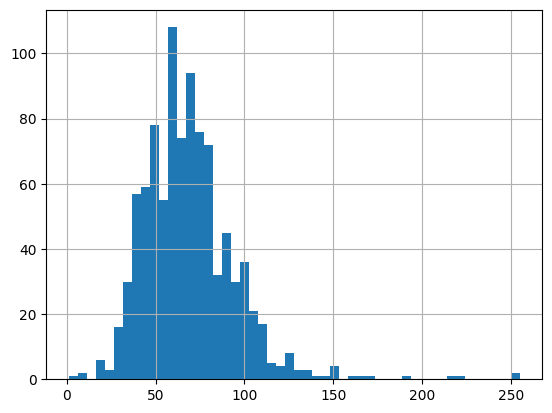

In [83]:
%matplotlib inline
pokemon_df["hp"].hist(bins=50)

---


## Transforming Data

- Most of the previous stuff has focused on exploring the data through summary statistics and subsetting
- However, another powerful element of Pandas is the ability to
- Pandas provides a bunch of mechanisms for manipulating your data


### Vectorized Math Operations

- When you perform a mathematical operation on a column, it will automatically apply that operation to every record/observation in the column.
- This is called a _vectorized_ operations
- It is like a Python `for` loop, but much faster


In [85]:
# compute the height/width ratio in a python loop
# We use the iterrows() function to make the dataframe behave like a list
for index, pokemon in pokemon_df.iterrows():
    print(
        pokemon["height"],
        "/",
        pokemon["weight"],
        "=",
        pokemon["height"] / pokemon["weight"],
    )

0.7 / 6.9 = 0.10144927536231883
1.0 / 13.0 = 0.07692307692307693
2.0 / 100.0 = 0.02
0.6 / 8.5 = 0.07058823529411765
1.1 / 19.0 = 0.05789473684210527
1.7 / 90.5 = 0.01878453038674033
0.5 / 9.0 = 0.05555555555555555
1.0 / 22.5 = 0.044444444444444446
1.6 / 85.5 = 0.01871345029239766
0.3 / 2.9 = 0.10344827586206896
0.7 / 9.9 = 0.0707070707070707
1.1 / 32.0 = 0.034375
0.3 / 3.2 = 0.09374999999999999
0.6 / 10.0 = 0.06
1.0 / 29.5 = 0.03389830508474576
0.3 / 1.8 = 0.16666666666666666
1.1 / 30.0 = 0.03666666666666667
1.5 / 39.5 = 0.0379746835443038
0.3 / 3.5 = 0.08571428571428572
0.7 / 18.5 = 0.03783783783783783
0.3 / 2.0 = 0.15
1.2 / 38.0 = 0.031578947368421054
2.0 / 6.9 = 0.2898550724637681
3.5 / 65.0 = 0.05384615384615385
0.4 / 6.0 = 0.06666666666666667
0.8 / 30.0 = 0.02666666666666667
0.6 / 12.0 = 0.049999999999999996
1.0 / 29.5 = 0.03389830508474576
0.4 / 7.0 = 0.05714285714285715
0.8 / 20.0 = 0.04
1.3 / 60.0 = 0.021666666666666667
0.5 / 9.0 = 0.05555555555555555
0.9 / 19.5 = 0.04615384615

- Gah! Divide by zero, thats annoying. If we wanted to do this in pure python we'd have to add a bunch of error handling.
- Or we could use PANDAS!


In [86]:
pokemon_df["height"] / pokemon_df["weight"]

id
1        0.101449
2        0.076923
3        0.020000
4        0.070588
5        0.057895
           ...   
10143    0.285714
10144    0.142857
10145    0.142857
10146    0.011566
10147    0.012422
Length: 949, dtype: float64

- Pandas didn't even break a sweat AND it handled the divide by zero case!
- Thanks Pandas! But how can we save that data?
- You can easy just create a new column with a Python assignment operator.


In [87]:
# Create a new column from the
pokemon_df["height_weight_ratio"] = pokemon_df["height"] / pokemon_df["weight"]

pokemon_df.head(10)

,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,...,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image,height_weight_ratio
id,,,,,,,,,,,,,,,,,,,,,
1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,49,...,45,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/7/7b/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.101449
2,ivysaur,2,1.0,13.0,142,grass,poison,60,62,63,...,60,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/a/a0/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.076923
3,venusaur,3,2.0,100.0,236,grass,poison,80,82,83,...,80,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/0/07/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.020000
4,charmander,4,0.6,8.5,62,fire,NaN,39,52,43,...,65,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/7/7d/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.070588
5,charmeleon,5,1.1,19.0,142,fire,NaN,58,64,58,...,80,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/b/be/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.057895
6,charizard,6,1.7,90.5,240,fire,flying,78,84,78,...,100,#F08030,#A890F0,#DE835E,monster,dragon,//archives.bulbagarden.net/media/upload/4/41/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.018785
7,squirtle,7,0.5,9.0,63,water,NaN,44,48,65,...,43,#6890F0,NaN,NaN,monster,water1,//archives.bulbagarden.net/media/upload/9/97/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.055556
8,wartortle,8,1.0,22.5,142,water,NaN,59,63,80,...,58,#6890F0,NaN,NaN,monster,water1,//archives.bulbagarden.net/media/upload/5/55/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.044444
9,blastoise,9,1.6,85.5,239,water,NaN,79,83,100,...,78,#6890F0,NaN,NaN,monster,water1,//archives.bulbagarden.net/media/upload/1/12/0...,1.0,https://raw.githubusercontent.com/HybridShivam...,0.018713


- You can also use vector operations with scalar values
- Pandas will automatically perform the operation on every value in the column


In [88]:
# convert feet to meters
pokemon_df["metric_height"] = pokemon_df["height"] * 0.3048
pokemon_df[["height", "metric_height"]].head(10)

,height,metric_height
id,,
1,0.7,0.21336
2,1.0,0.30480
3,2.0,0.60960
4,0.6,0.18288
5,1.1,0.33528
6,1.7,0.51816
7,0.5,0.15240
8,1.0,0.30480
9,1.6,0.48768


### Vectorized String Operations

- Sometimes you need to clean string or categorical data
- Pandas has a set of String operations that do this work for you
- Especially useful for handling bad data!


In [89]:
data = ["peter", "Paul", "MARY", "gUIDO"]

for s in data:
    print(s.capitalize())

Peter
Paul
Mary
Guido


- But like above, this breaks very easily with missing values


In [96]:
data = ["peter", "Paul", None, "MARY", "gUIDO"]

# for s in data:
#     print(s.capitalize())

- The Pandas library has _vectorized string operations_ that handle missing data


In [98]:
names = pd.Series(["peter", "Paul", None, "MARY", "gUIDO"])
names

0    peter
1     Paul
2     None
3     MARY
4    gUIDO
dtype: object

In [99]:
names.str.capitalize()


0    Peter
1     Paul
2     None
3     Mary
4    Guido
dtype: object

- Look ma! No errors!
- Pandas includes a a bunch of methods for doing things to strings.

|            |                |                |                |
| ---------- | -------------- | -------------- | -------------- |
| `len()`    | `lower()`      | `translate()`  | `islower()`    |
| `ljust()`  | `upper()`      | `startswith()` | `isupper()`    |
| `rjust()`  | `find()`       | `endswith()`   | `isnumeric()`  |
| `center()` | `rfind()`      | `isalnum()`    | `isdecimal()`  |
| `zfill()`  | `index()`      | `isalpha()`    | `split()`      |
| `strip()`  | `rindex()`     | `isdigit()`    | `rsplit()`     |
| `rstrip()` | `capitalize()` | `isspace()`    | `partition()`  |
| `lstrip()` | `swapcase()`   | `istitle()`    | `rpartition()` |

#### Exercise

- In the cells below, try three of the string operations listed above on the Pandas Series `monte`
- Remember, you can hit tab to autocomplete and shift-tab to see documentation


In [100]:
monte = pd.Series(
    [
        "Graham Chapman",
        "John Cleese",
        "Terry Gilliam",
        "Eric Idle",
        "Terry Jones",
        "Michael Palin",
    ]
)
monte

0    Graham Chapman
1       John Cleese
2     Terry Gilliam
3         Eric Idle
4       Terry Jones
5     Michael Palin
dtype: object

In [101]:
# First
monte.str.startswith("T")

0    False
1    False
2     True
3    False
4     True
5    False
dtype: bool

In [102]:
# Second
monte.str.isdigit()

0    False
1    False
2    False
3    False
4    False
5    False
dtype: bool

In [103]:
# Third
monte.str.zfill(15)

0    0Graham Chapman
1    0000John Cleese
2    00Terry Gilliam
3    000000Eric Idle
4    0000Terry Jones
5    00Michael Palin
dtype: object

![Pandas will F you up!](https://media1.giphy.com/media/EPcvhM28ER9XW/giphy.gif)


---


- OK, thats it.
- WE DID IT!

![Celebration](https://media2.giphy.com/media/1ofR3QioNy264/giphy.gif)


## Further Readings and Resources

- Python for Everybody - https://www.py4e.com/
- Python Data Science Handbook - https://jakevdp.github.io/PythonDataScienceHandbook/index.html
- Dataquest Online tutorials - https://Dataquest.io
- Python Documentation - https://docs.python.org
- Pandas Documentation - https://pandas.pydata.org/pandas-docs/stable/
